In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from xspec import *

Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

#https://heasarc.gsfc.nasa.gov/docs/xanadu/xspec/python/html/quick.html
#https://github.com/mfacorcoran/pyxspec-tutorial/blob/master/PyXspec-TheExtendedTutorial.ipynb
# https://johannesbuchner.github.io/BXA/tutorial_usage_plotxspec.html
#https://gist.github.com/ivvv/716799056b4aadc87e41097472edbd20


sh: 1: source: not found


ModuleNotFoundError: No module named 'xspec'

<span style='color:green'> First plot Aeff  </span>

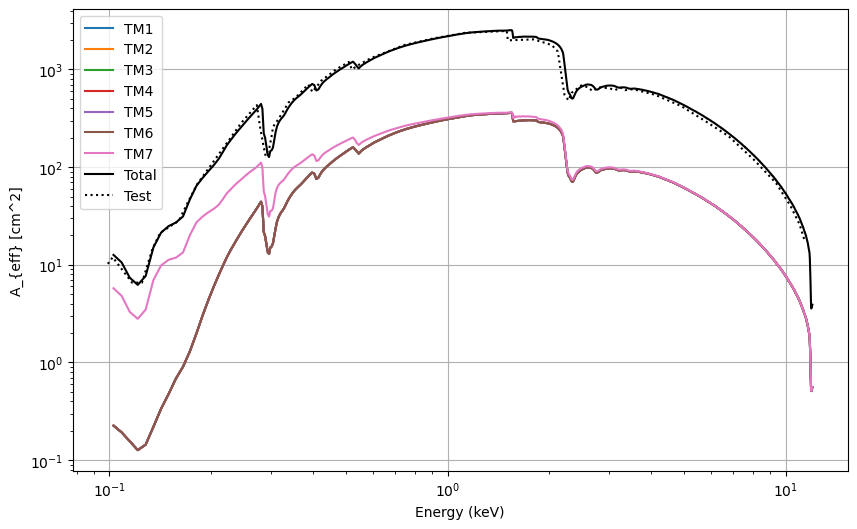

In [66]:
#arf1 = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_arf_filter_000101v02.fits")
#arf1.info()
arf1test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_arf_filter_000101v02.fits")['SPECRESP']
#print(arf1test.header)
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.

arf2test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm2_arf_filter_000101v02.fits")['SPECRESP']
arf2ELOW = arf2test.data.field('ENERG_LO')#keV
arf2EHI = arf2test.data.field('ENERG_HI')#keV
arf2Aeff = arf2test.data.field('SPECRESP')#cm2
arf2E = (arf2ELOW + arf2EHI)/2.

arf3test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm3_arf_filter_000101v02.fits")['SPECRESP']
arf3ELOW = arf3test.data.field('ENERG_LO')#keV
arf3EHI = arf3test.data.field('ENERG_HI')#keV
arf3Aeff = arf3test.data.field('SPECRESP')#cm2
arf3E = (arf3ELOW + arf3EHI)/2.

arf4test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm4_arf_filter_000101v02.fits")['SPECRESP']
arf4ELOW = arf4test.data.field('ENERG_LO')#keV
arf4EHI = arf4test.data.field('ENERG_HI')#keV
arf4Aeff = arf4test.data.field('SPECRESP')#cm2
arf4E = (arf4ELOW + arf4EHI)/2.

arf5test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm5_arf_filter_000101v02.fits")['SPECRESP']
arf5ELOW = arf5test.data.field('ENERG_LO')#keV
arf5EHI = arf5test.data.field('ENERG_HI')#keV
arf5Aeff = arf5test.data.field('SPECRESP')#cm2
arf5E = (arf5ELOW + arf5EHI)/2.

arf6test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm6_arf_filter_000101v02.fits")['SPECRESP']
arf6ELOW = arf6test.data.field('ENERG_LO')#keV
arf6EHI = arf6test.data.field('ENERG_HI')#keV
arf6Aeff = arf6test.data.field('SPECRESP')#cm2
arf6E = (arf6ELOW + arf6EHI)/2.

arf7test = fits.open("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm7_arf_filter_000101v02.fits")['SPECRESP']
arf7ELOW = arf7test.data.field('ENERG_LO')#keV
arf7EHI = arf7test.data.field('ENERG_HI')#keV
arf7Aeff = arf7test.data.field('SPECRESP')#cm2
arf7E = (arf7ELOW + arf7EHI)/2.

dataAeff = np.genfromtxt('/Users/marcotaoso/Documents/2024/eROSITA/testLMC/Data/eROSITA_aeff.csv', delimiter=',',filling_values=0)


fig, ax = plt.subplots(figsize=(10,6))
# # Plot using Matplotlib:
ax.plot(arf1E, arf1Aeff,label='TM1')
ax.plot(arf2E, arf2Aeff,label='TM2')
ax.plot(arf3E, arf2Aeff,label='TM3')
ax.plot(arf4E, arf2Aeff,label='TM4')
ax.plot(arf5E, arf2Aeff,label='TM5')
ax.plot(arf6E, arf2Aeff,label='TM6')
ax.plot(arf7E, arf7Aeff,label='TM7')
ax.plot(arf7E, arf1Aeff+arf2Aeff+arf3Aeff+arf4Aeff+arf5Aeff+arf6Aeff+arf7Aeff,label='Total',color='black',linestyle='solid')
ax.plot(dataAeff[:,0], dataAeff[:,1],label='Test',color='black',linestyle='dotted')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'A_{eff} [cm^2]')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

<span style='color:green'> Load the data  </span>

In [2]:
# From https://github.com/mfacorcoran/pyxspec-tutorial/blob/master/PyXspec-TheExtendedTutorial.ipynb

s1 = Spectrum("/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/LMC_TM1_pha.fits")
try:
    b1 = s1.background
except Exception:
    b1 = ''
b1='' # spectrum has no background
try: 
    r1 = s1.response
except Exception:
    r1='' # no response defined
try:
    arfFileName = r1.arf
except Exception:
    arfFileName = '' # no arf defined either


if not r1:
    s1.response = "/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_rmf_141103v02.fits"
    print("New Response = {0}".format(s1.response.rmf))

s1.response.arf = "/Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_arf_filter_000101v02.fits"
print("New ARF = {0}".format(s1.response.arf))

# check the data
AllData.show()

***Warning: Data file /Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/LMC_TM1_pha.fits has both POISSERR key set to 'true' and a STAT_ERR column.
   XSPEC will assume Poisson errors.
New Response = /Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_rmf_141103v02.fits
New ARF = /Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/tm1_arf_filter_000101v02.fits

 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromMichela/Spectra_irfs_v3/LMC_TM1_pha.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.088e+03 +/- 2.714e+00
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: CCD  Channel Type: PI
  Exposure Time: 147.7 sec
  Filtering Keys: 
    Stokes: 0
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Spectrum 1 h

Error: cannot read response file /Users/mnegro/opt/anaconda3/envs/threeML/lib/python3.9/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/rmf/ixpe_d1_obssim_v012.rmf


<span style='color:green'> Ignore some channels  </span>

In [14]:
s1.ignore("1-73") # 0-72 ignore channels 20 to 30 and all channels above 50 keV
s1.ignore("927-1024") #"926-1023"
#print("Noticed Channels:")
#for no in s1.noticed:
#    print(no)

    73 channels (1,73) ignored in spectrum #     1

    98 channels (927,1024) ignored in spectrum #     1



<span style='color:green'> First plot with /xs or /xw  </span>

In [42]:
Plot.device = "/xs"

In [43]:
Plot.xAxis = "keV"
Plot("data")

 specfit.qdp exists, reuse it?  PLT--Unable to open specfit.qdp


<span style='color:green'> Now instead use python matplotlib to plot the data. Plot as a function of the channels </span>

In [15]:
# reset the plot
Plot.commands = ()

Plot command list is now empty


In [16]:
# https://gist.github.com/ivvv/716799056b4aadc87e41097472edbd20 (look here if you have also model with sum of components)
#https://github.com/elastufka/solar_all_purpose/blob/main/pyXspec%20test.ipynb
#Save the data
save_data = 'specfit_ch.qdp'
if (os.path.isfile(save_data)):
    os.remove(save_data)
# following Andy Beardmore idea
Plot.device = '/null'
Plot.add = True
Plot.addCommand(f'wd {save_data}')
Plot.xAxis = "channel"
Plot("ldata") 
# Read the data
names = ['e','de','rate','rate_err']
df = pd.read_table('specfit_ch.qdp',skiprows=3,names=names, delimiter=' ')
df

,e,de,rate,rate_err
0,74,0.5,0.373482,0.050290
1,75,0.5,1.086493,0.085774
2,76,0.5,1.188352,0.089705
3,77,0.5,1.521091,0.101490
4,78,0.5,1.453185,0.099198
...,...,...,...,...
848,922,0.5,0.312367,0.045991
849,923,0.5,0.339529,0.047949
850,924,0.5,0.258042,0.041801
851,925,0.5,0.305576,0.045489


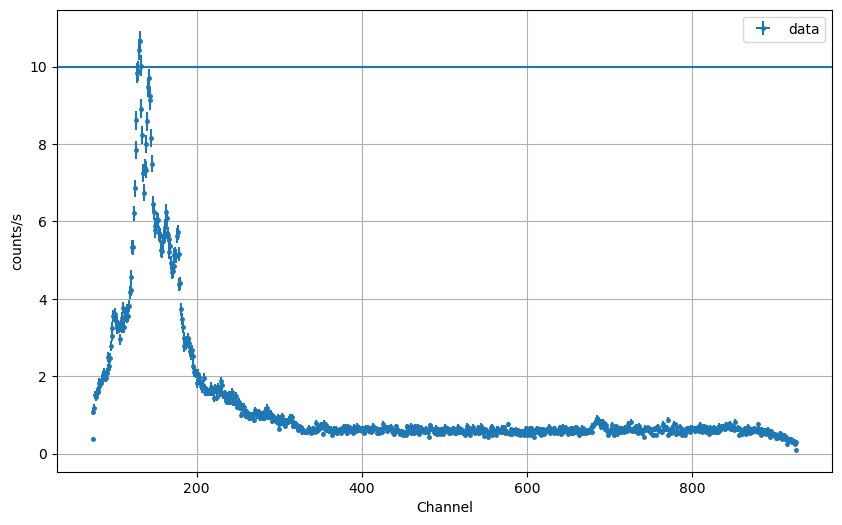

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
# # Plot using Matplotlib:
ax.errorbar(df.e, df.rate, xerr=df.de,yerr=df.rate_err,fmt='.',markersize='5',label='data')
ax.axhline(y=10)
ax.set_xlabel('Channel')
ax.set_ylabel(r'counts/s')
#ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()
#plt.show();

<span style='color:green'> Now instead use python matplotlib to plot the data. Plot as a function of the energy  </span>

In [18]:
# reset the plot
Plot.commands = ()

Plot command list is now empty


In [19]:
# https://gist.github.com/ivvv/716799056b4aadc87e41097472edbd20 (look here if you have also model with sum of components)
#https://github.com/elastufka/solar_all_purpose/blob/main/pyXspec%20test.ipynb
#Save the data
save_data = 'specfit.qdp'
if (os.path.isfile(save_data)):
    os.remove(save_data)
# following Andy Beardmore idea
Plot.device = '/null'
Plot.add = True
Plot.addCommand(f'wd {save_data}')
Plot.xAxis = "keV"
Plot("ldata") 
# Read the data
names = ['e','de','rate','rate_err']
df = pd.read_table('specfit.qdp',skiprows=3,names=names, delimiter=' ')
df

,e,de,rate,rate_err
0,0.498726,0.002981,62.634529,8.433788
1,0.504696,0.002989,181.756241,14.348931
2,0.510681,0.002996,198.295654,14.968710
3,0.516682,0.003004,253.188889,16.893158
4,0.522697,0.003011,241.287338,16.470919
...,...,...,...,...
848,9.930827,0.008677,18.000681,2.650332
849,9.948200,0.008696,19.521969,2.756949
850,9.965612,0.008717,14.801795,2.397799
851,9.983067,0.008737,17.487309,2.603196


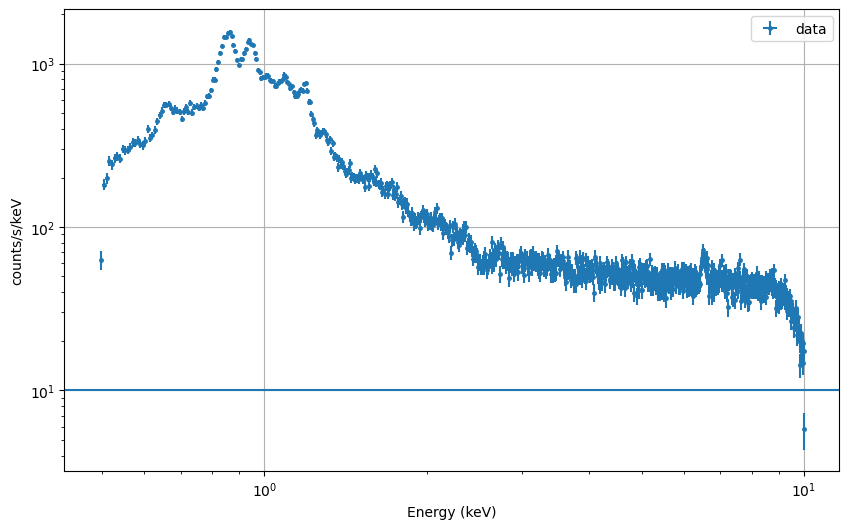

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
# # Plot using Matplotlib:
ax.errorbar(df.e, df.rate, xerr=df.de,yerr=df.rate_err,fmt='.',markersize='5',label='data')
ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()
#plt.show();

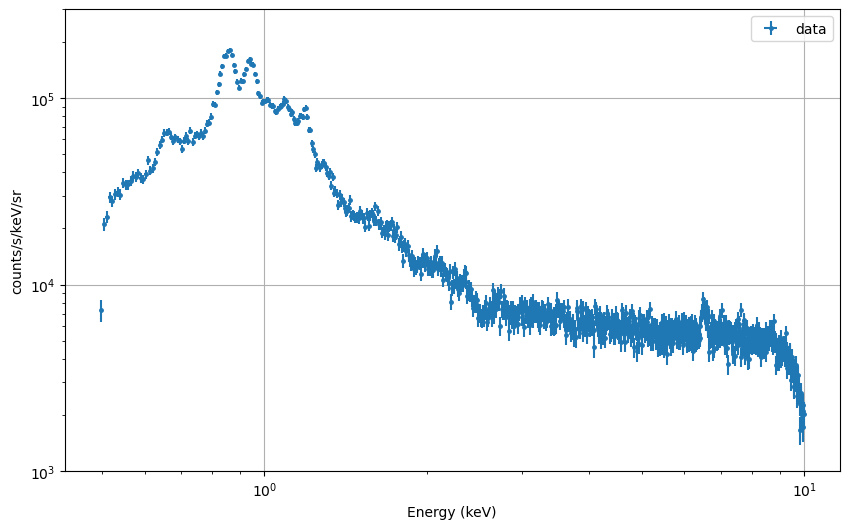

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
# # Plot using Matplotlib:
deltaOmega=2*np.pi*(1.-np.cos(3*np.pi/180.))
rate_new = df.rate/deltaOmega
rate_err_new = df.rate_err/deltaOmega
ax.errorbar(df.e, rate_new, xerr=df.de,yerr=rate_err_new,fmt='.',markersize='5',label='data')
ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV/sr')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((1000,3e5))
ax.grid()
ax.legend()
np.savetxt('Flux.txt', list(zip(df.e,df.de,rate_new,rate_err_new)),fmt='%1.5f')

In [21]:
ven=Plot.x()
vRate=Plot.y()
#ven=df.e
print("Min energy ",np.min(ven)," Max energy ",np.max(ven)," number bins ",len(ven))
print("Min Rate ",np.min(vRate)," Max Rate ",np.max(vRate))
# Calculate the bin widths,
bin_widths = np.diff(ven)
print("Min max bin widths ",np.min(bin_widths)," ",np.max(bin_widths))
print(" ",ven[90]," ",bin_widths[90]," ",ven[91]-ven[90],)

Min energy  0.4987258166074753  Max energy  10.000561714172363  number bins  853
Min Rate  5.814821462597997  Max Rate  1562.2670777615708
Min max bin widths  0.005970314145088196   0.01749563217163086
  1.0965567231178284   0.007332444190979004   0.007332444190979004


In [4]:
#https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/Models.html
model = Model("phabs*(vapec + vapec + powerlaw )")
#model = Model("phabs*(po + po)")
Fit.nIterations=1000
Fit.perform()


Model phabs<1>(vapec<2> + vapec<3> + powerlaw<4>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   phabs      nH         10^22    1.00000      +/-  0.0          
   2    2   vapec      kT         keV      6.50000      +/-  0.0          
   3    2   vapec      He                  1.00000      frozen
   4    2   vapec      C                   1.00000      frozen
   5    2   vapec      N                   1.00000      frozen
   6    2   vapec      O                   1.00000      frozen
   7    2   vapec      Ne                  1.00000      frozen
   8    2   vapec      Mg                  1.00000      frozen
   9    2   vapec      Al                  1.00000      frozen
  10    2   vapec      Si                  1.00000      frozen
  11    2   vapec      S                   1.00000      frozen
  12    2   vapec      Ar                  1.00000      frozen
  13    2   vapec      Ca                  1.00000      frozen
  14    2   vapec   

In [6]:
# reset the plot
Plot.commands = ()
Plot.device = "/xs"
Plot.xAxis = "keV"
Plot("ldata","delchi")

Plot command list is now empty


In [5]:
#Fit.nIterations=1000
Fit.perform()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH          2:kT       17:norm         18:kT       33:norm   34:PhoIndex       35:norm
7719.51      15.0323      -1      0.138486      0.879701       2.36739       3.25181       8.77002      -2.29710      0.120163
 Variances and Principal Axes
                 1        2       17       18       33       34       35  
 2.8684E-07| -0.0284   0.0006   0.0020   0.0005   0.0016  -0.2017   0.9790  
 9.4057E-07|  0.9625   0.2623  -0.0612   0.0092  -0.0119  -0.0133   0.0251  
 7.4649E-06| -0.2608   0.9643   0.0164  -0.0274   0.0167   0.0267  -0.0027  
 1.6089E-04| -0.0182   0.0232  -0.0457  -0.0134  -0.0720  -0.9753  -0.2012  
 7.8625E-04|  0.0641  -0.0010   0.9932  -0.0815   0.0245  -0.0465  -0.0098  
 3.6210E-03|  0.0154  -0.0268  -0.0863  -0.9081   0.4084  -0.0140  -0.0025  
 1.8547E-02| -0.0074   0.0003  -0.0073  -0.4096  -0.9094   0.0700   0.0159  
--------------------------------------------------------

In [97]:
# This displays all parameters in all model objects:
#model.show()
#Show the selected model parameters
#AllModels.show("1-2, 17-18, 33-34, 49-53")
print("chi2 is ",Fit.testStatistic," dof ",Fit.dof)
#ncomp = len(model.componentNames)
#for icomp in model.componentNames:
#    print (icomp,eval(f'model.{icomp}.parameterNames'))

print('***************')
print("value is ",model.phabs.nH.values)
#Change the value
model.phabs.nH = 5.3
#Show that the value changed
print("new value ",print("value is ",model.phabs.nH.values))

print('***************')
print("value of T ",model(2).values)
#Change the value
model(2).values = 7.1
#Show that the value changed
print("value of T ",model(2).values)
#AllModels.show("2")


chi2 is  7719.506774903242  dof  846
***************
value is  [0.13848613572452445, 0.0013848613572452445, 0.0, 0.0, 100000.0, 1000000.0]

Fit statistic  : Chi-Squared                111071.0     using 853 bins.

Test statistic : Chi-Squared                111071.0     using 853 bins.
 Null hypothesis probability of 0.0e+00 with 846 degrees of freedom
 Current data and model not fit yet.
value is  [5.3, 0.053, 0.0, 0.0, 100000.0, 1000000.0]
new value  None
***************
value of T  [0.8797007679689892, 0.008797007679689892, 0.0808, 0.0808, 68.447, 68.447]

Fit statistic  : Chi-Squared                110721.2     using 853 bins.

Test statistic : Chi-Squared                110721.2     using 853 bins.
 Null hypothesis probability of 0.0e+00 with 846 degrees of freedom
 Current data and model not fit yet.
value of T  [7.1, 0.071, 0.0808, 0.0808, 68.447, 68.447]


In [93]:
# Remove all copies of ALL model definitions
AllModels.clear()

In [94]:
AllModels.show()


Parameters defined: none
